In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime as dt

In [2]:
df = pd.read_csv("../data/Walmart.csv")

In [3]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [5]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [6]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

### Any store must have only one record in a day.

In [7]:
duplicates = df.duplicated(subset=["Store", "Date"]).sum()
duplicates

np.int64(0)

### We should Use datetime to be comfortable with date because date datatype is string.

In [8]:
df["Date"] = pd.to_datetime(df["Date"], format='%d-%m-%Y')
df["Date"].head(10)

0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
5   2010-03-12
6   2010-03-19
7   2010-03-26
8   2010-04-02
9   2010-04-09
Name: Date, dtype: datetime64[us]

In [ ]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week
df["Day Of Week"] = df["Date"].dt.day_of_week #Monday = 0 - Saturday = 6

In [10]:
df["Is Holiday"] = df["Holiday_Flag"].astype(bool)

In [11]:
df[["Year","Month","Week","Day Of Week","Is Holiday"]].head(10)

,Year,Month,Week,Day Of Week,Is Holiday
0,2010,2,5,4,False
1,2010,2,6,4,True
2,2010,2,7,4,False
3,2010,2,8,4,False
4,2010,3,9,4,False
5,2010,3,10,4,False
6,2010,3,11,4,False
7,2010,3,12,4,False
8,2010,4,13,4,False
9,2010,4,14,4,False


In [12]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day Of Week
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.0,6435.0
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,2010.965035,6.447552,25.818182,4.0
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000,1.0,4.0
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,2010.000000,4.000000,14.0,4.0
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,2011.000000,6.000000,26.0,4.0
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,2012.000000,9.000000,38.0,4.0
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,2012.000000,12.000000,52.0,4.0
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.797019,3.238308,14.129201,0.0


### Which Store had most sale per week

In [15]:
df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(1)

Store
20    3.013978e+08
Name: Weekly_Sales, dtype: float64

### Is "20" Store always had most Weekly sale or not?

In [18]:
sale_by_store = df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)

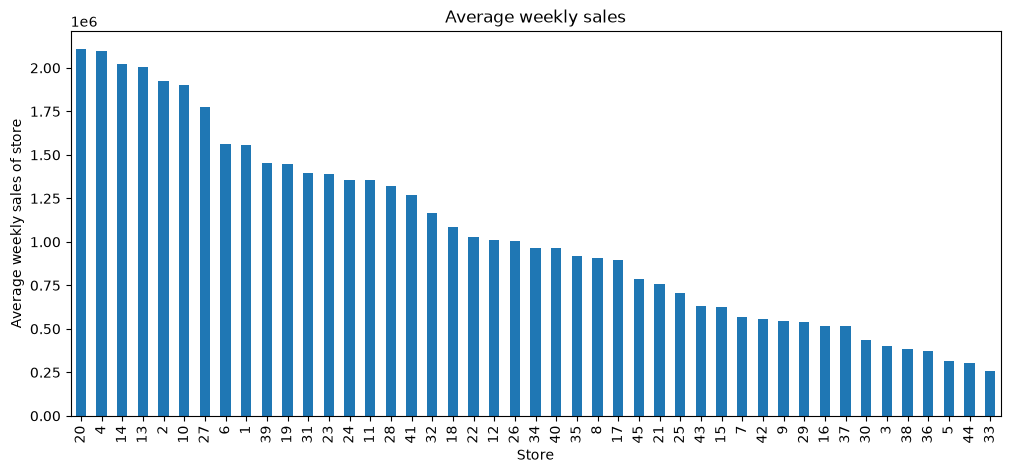

In [19]:
sale_by_store.plot(figsize=(12,5), kind="bar")

plt.xlabel("Store")
plt.ylabel("Average weekly sales of store")
plt.title("Average weekly sales")
plt.show()

### Weekly Sales per year

In [21]:
df.groupby("Year")["Weekly_Sales"].sum()

Year
2010    2.288886e+09
2011    2.448200e+09
2012    2.000133e+09
Name: Weekly_Sales, dtype: float64

### Average Weekly Sales per year

In [22]:
df.groupby("Year")["Weekly_Sales"].mean()

Year
2010    1.059670e+06
2011    1.046239e+06
2012    1.033660e+06
Name: Weekly_Sales, dtype: float64

### Average Weekly Sales per month

In [24]:
df.groupby("Month")["Weekly_Sales"].mean().sort_values(ascending=False)

Month
12    1.281864e+06
11    1.147266e+06
6     1.064325e+06
2     1.053200e+06
8     1.048017e+06
7     1.031748e+06
5     1.031714e+06
4     1.026762e+06
3     1.013309e+06
10    9.996321e+05
9     9.893353e+05
1     9.238846e+05
Name: Weekly_Sales, dtype: float64

### Do holidays affect sales?

In [25]:
df.groupby("Holiday_Flag")["Weekly_Sales"].mean().sort_values(ascending=False)

Holiday_Flag
1    1.122888e+06
0    1.041256e+06
Name: Weekly_Sales, dtype: float64

In [26]:
df["Holiday_Flag"].value_counts()

Holiday_Flag
0    5985
1     450
Name: count, dtype: int64

In [27]:
df["Holiday_Flag"].value_counts(normalize=True)*100

Holiday_Flag
0    93.006993
1     6.993007
Name: proportion, dtype: float64

In [28]:
df.groupby("Month")["Holiday_Flag"].sum()

Month
1       0
2     135
3       0
4       0
5       0
6       0
7       0
8       0
9     135
10      0
11     90
12     90
Name: Holiday_Flag, dtype: int64